# Wan TI2V Causal Window and SSM Memory

This notebook uses the `new` conda environment/kernel. The shared local attention is causal and frame-blocked: query tokens in latent frame `f` attend to frames `[f-l, ..., f]` with temporal RoPE applied relative to that local window. Training uses standard Wan flow matching: frame 0 is kept clean as the input/mask frame, future latent frames are noised with sigmas from the Wan UniPC scheduler, and the model predicts velocity (`noise - clean`) with timestep AdaLN conditioning enabled. The clean first latent frame is also provided through the per-block AdaLN0 first-frame conditioner; text conditioning remains disabled. Evaluation samples with the Wan `FlowUniPCMultistepScheduler` for `EVAL_INFERENCE_STEPS=20`. It filters the dataset by safetensor latent-frame count and progressively truncates batches up to `LATENT_FRAME_COUNT` inside the training path. The current stacked-vorticity videos are 256x256 images, which Wan TI2V VAE stores as 16x16 spatial latents.


In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name != "navier":
    NOTEBOOK_DIR = Path("/home/azureuser/physics/navier")
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

import autoreg_windowed_lora as awl

print(sys.executable)
print("device:", awl.DEVICE)

/opt/miniforge/envs/new/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/opt/miniforge/envs/new/bin/python
device: cuda


In [2]:
import torch

CONFIG = dict(
    LATENT_ROOT=Path("/home/azureuser/datasets/navier_with_vorticity"),
    WAN_REPO_ROOT=Path("/home/azureuser/physics/navier/Wan2.2"),
    WAN_CHECKPOINT_DIR=Path("/home/azureuser/Wan2.2-TI2V-5B"),
    OUTPUT_DIR=Path("/home/azureuser/physics/navier/autoreg_lora_outputs"),
    DEVICE=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    PARAM_DTYPE=torch.bfloat16,
    TRAIN_DTYPE=torch.bfloat16,
    BATCH_SIZE=2,
    GRAD_ACCUM_STEPS=2,
    LEARNING_RATE=1e-4,
    LR_WARMUP_STEPS=1,
    MAX_STEPS=30000,
    CLIP_GRAD_NORM=1.0,
    LOSS_EMA_BETA=0.99,
    TRANSFORMER_DROPPED_LAYERS=(
        # 4, 5,
        # 6, 7, 
        # 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 
        # 24, 25, 26
    ),
    TRAIN_RANDOM_LAYER_DROP=False,
    GRADIENT_CHECKPOINT_DISABLE_BLOCKS="all",
    TRAIN_INIT_LOGS=True,
    REGIONAL_COMPILE=False,
    REGIONAL_COMPILE_BACKEND="inductor",
    REGIONAL_COMPILE_MODE="reduce-overhead",
    REGIONAL_COMPILE_FULLGRAPH=False,
    REGIONAL_COMPILE_DYNAMIC=False,
    REGIONAL_COMPILE_CAPTURE_SCALAR_OUTPUTS=True,
    USE_FLEX_ATTENTION=True,
    FLEX_ATTENTION_BLOCK_SIZE=128,
    FLEX_ATTENTION_DYNAMIC=True,
    FLEX_ATTENTION_RECOMPILE_LIMIT=64,
    FIRST_FRAME_CONDITIONING_DIM=32,
    WAN_NUM_TRAIN_TIMESTEPS=1000,
    WAN_SAMPLE_SHIFT=5.0,
    EVAL_INFERENCE_STEPS=20,
    WINDOW_LEFT_FRAMES=1,
    WINDOW_RIGHT_FRAMES=0,
    MIN_LATENT_FRAME_COUNT=12,
    LATENT_FRAME_COUNT=40,
    PROGRESSIVE_SEQUENCE_LENGTH_START=6,
    PROGRESSIVE_SEQUENCE_LENGTH_STEP_INTERVAL=200,
    HOLDOUT_COUNT=100,
    EVAL_EVERY=500,
    EVAL_FPS=32,
    EVAL_ERROR_VMAX=0.45,
    # Stacked-vorticity videos are 256x256; Wan TI2V VAE spatial stride is 16, so latents are 16x16.
    VIDEO_OUTPUT_SIZE=256,
    SAVE_EVERY=None,
    WANDB_ENABLED=True,
    WANDB_PROJECT="navier-autoreg",
    WANDB_ENTITY=None,
    WANDB_RUN_NAME=None,
    WANDB_MODE=None,
    WANDB_TAGS=("ssm-window", "lora"),
    WANDB_LOG_DEBUG_VIDEOS=True,
    WANDB_FRAME_LOSS_TIMESTEPS=(0, 5, 10, 15, 20, 25, 30, 35, 40),
    LORA_R=16,
    LORA_ALPHA=16,
    LORA_DROPOUT=0.0,
    LORA_TARGET_MODULES=[
        "self_attn.q",
        "self_attn.k",
        "self_attn.v",
        "self_attn.o",
        "ffn.0",
        "ffn.2",
    ],
    PATCH_EMBEDDING_LORA_R=16,
    PATCH_EMBEDDING_LORA_ALPHA=16,
    TIMESTEP_ADALN_LORA_R=16,
    TIMESTEP_ADALN_LORA_ALPHA=16,
    SSM_DECAY_INIT=0.9,
    SSM_INPUT_INIT=1e-1,
    SSM_OUTPUT_INIT=1.0,
    SSM_SKIP_INIT=0.0,
    SSM_RHO_INIT=1e-2,
    SSM_FREEZE_RHO_ZERO=False,
    SSM_QUERY_SCALE=None,
    SSM_LAYER_COUNT=30,
    SSM_RECURRENT_DIM=256,
    SSM_STATE_MIXER_EXPANSION=1,
    SSM_USE_CONVOLUTIONS=False,
    REQUIRE_RHO=True,
    RANDOM_SEED=1234,
)

awl.configure(**CONFIG)
for key, value in awl.get_config().items():
    print(f"{key}: {value}")

LATENT_ROOT: /home/azureuser/datasets/navier_with_vorticity
WAN_REPO_ROOT: /home/azureuser/physics/navier/Wan2.2
WAN_CHECKPOINT_DIR: /home/azureuser/Wan2.2-TI2V-5B
OUTPUT_DIR: /home/azureuser/physics/navier/autoreg_lora_outputs
DEVICE: cuda
PARAM_DTYPE: torch.bfloat16
TRAIN_DTYPE: torch.bfloat16
BATCH_SIZE: 2
GRAD_ACCUM_STEPS: 2
LEARNING_RATE: 0.0001
LR_WARMUP_STEPS: 1
MAX_STEPS: 30000
CLIP_GRAD_NORM: 1.0
LOSS_EMA_BETA: 0.99
TRANSFORMER_DROPPED_LAYERS: ()
TRAIN_RANDOM_LAYER_DROP: False
GRADIENT_CHECKPOINT_DISABLE_BLOCKS: all
TRAIN_INIT_LOGS: True
REGIONAL_COMPILE: False
REGIONAL_COMPILE_BACKEND: inductor
REGIONAL_COMPILE_MODE: reduce-overhead
REGIONAL_COMPILE_FULLGRAPH: False
REGIONAL_COMPILE_DYNAMIC: False
REGIONAL_COMPILE_CAPTURE_SCALAR_OUTPUTS: True
USE_FLEX_ATTENTION: True
FLEX_ATTENTION_BLOCK_SIZE: 128
FLEX_ATTENTION_DYNAMIC: True
FLEX_ATTENTION_RECOMPILE_LIMIT: 64
FIRST_FRAME_CONDITIONING_DIM: 32
WAN_NUM_TRAIN_TIMESTEPS: 1000
WAN_SAMPLE_SHIFT: 5.0
EVAL_INFERENCE_STEPS: 20
WINDOW_

In [3]:
import torch

grid = torch.tensor([[4, 2, 3]])
mask = awl.frame_window_mask(grid, seq_len=24, left_frames=1, right_frames=0)[0]
assert torch.where(mask[0])[0].tolist() == list(range(6))
assert torch.where(mask[12])[0].tolist() == list(range(6, 18))
assert torch.where(mask[18])[0].tolist() == list(range(12, 24))
print("mask ok: causal left window without first-frame anchor")


mask ok: causal left window without first-frame anchor


In [4]:
samples = awl.discover_latent_samples()
train_samples, holdout_samples = awl.make_splits(samples)
print(f"latents: {len(samples):,}")
print(f"train: {len(train_samples):,}")
print(f"holdout: {len(holdout_samples):,}")
print("example:", samples[0].latents_path)


[sample discovery] checking 2,000 latent files in /home/azureuser/datasets/navier_with_vorticity (min latent frames=12)
[sample discovery] checked 500/2,000; kept 500; elapsed 0.0s
[sample discovery] checked 1,000/2,000; kept 1,000; elapsed 0.1s
[sample discovery] checked 1,500/2,000; kept 1,500; elapsed 0.1s


[sample discovery] done in 0.2s; kept 2,000; skipped_short=0; skipped_bad_latents=0; skipped_metadata=0
latents: 2,000
train: 1,900
holdout: 100
example: /home/azureuser/datasets/navier_with_vorticity/0012232107d82029/latents.safetensors


[train init] train_ssm_window(flow_matching, max_steps=30000) starting
[train init] build SSM window objects ...
[train init] mode=flow_matching device=cuda param_dtype=torch.bfloat16 train_dtype=torch.bfloat16
[train init] Wan scheduler flow matching: clean frame 0, noisy future frames, shift=5, eval_steps=20
[train init] discover latent samples ...
[sample discovery] checking 2,000 latent files in /home/azureuser/datasets/navier_with_vorticity (min latent frames=12)
[sample discovery] checked 500/2,000; kept 500; elapsed 0.0s
[sample discovery] checked 1,000/2,000; kept 1,000; elapsed 0.1s


[sample discovery] checked 1,500/2,000; kept 1,500; elapsed 0.1s
[sample discovery] done in 0.2s; kept 2,000; skipped_short=0; skipped_bad_latents=0; skipped_metadata=0
[train init] discover latent samples done in 0.2s
[train init] found 2,000 samples in /home/azureuser/datasets/navier_with_vorticity
[train init] split dataset and compute physics stats ...
[train init] split dataset and compute physics stats done in 0.0s
[train init] train=1,900 holdout=100
[train init] text conditioning disabled; timestep AdaLN conditioning enabled
[train init] create latent dataset and dataloader ...
[train init] create latent dataset and dataloader done in 0.0s
[train init] load student Wan transformer from /home/azureuser/Wan2.2-TI2V-5B ...


Loading checkpoint shards: 100%|██████████| 3/3 [00:00<00:00,  3.14it/s]


[train init] load student Wan transformer from /home/azureuser/Wan2.2-TI2V-5B done in 1.9s
[train init] attach student physics conditioning and SSM memory ...
[train init] attach student physics conditioning and SSM memory done in 0.5s
[train init] attach student LoRA adapters ...
[train init] attach student LoRA adapters done in 0.7s
[train init] configure student gradient checkpointing ...
gradient checkpointing enabled on 0/30 blocks; disabled blocks: all
[train init] configure student gradient checkpointing done in 0.0s
[train init] enable SSM/windowed student training ...
[train init] enable SSM/windowed student training done in 0.0s
[train init] regionally compile student repeated Wan blocks ...
[train init] regionally compile student repeated Wan blocks done in 0.0s
[train init] create optimizer ...
[train init] create optimizer done in 0.0s
SSM window trainable params: 145,406,238 / 5,145,193,950 (init=pretrained, ssm=77,053,470, lora=28,508,160, patch_lora=52,224, timestep_lor

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/azureuser/.netrc.
wandb: Currently logged in as: odusseys to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


...

[train init] active latent frame count at step 201: 7


ssm-window:   1%|▏         | 400/30000 [05:16<6:35:18,  1.25it/s, mse_ema=0.092384, seq=7, total_ema=0.092384]

[train init] active latent frame count at step 401: 8


ssm-window:   2%|▏         | 499/30000 [06:40<6:46:10,  1.21it/s, mse_ema=0.073145, seq=8, total_ema=0.073145]

step 500: 8a55df4b7f80f131 | nu=2.31e-03, rho=1.3 | left=ssm Wan flow 20 steps causal window L=1 | middle=ground truth | right=absolute error
pred_latents: min=-4.844, max=5.656, mean=-0.149, std=1.469 | gt_latents: min=-4.945, max=5.488, mean=-0.153, std=1.472 | pred_video: min=-1.000, max=1.000, mean=0.257, std=0.538 | gt_video: min=-1.000, max=1.000, mean=0.268, std=0.533


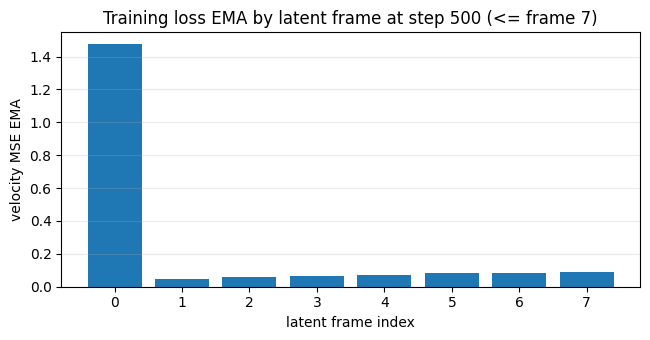

ssm-window:   2%|▏         | 600/30000 [08:07<7:19:44,  1.11it/s, mse_ema=0.057520, seq=8, total_ema=0.057520] 

[train init] active latent frame count at step 601: 9


ssm-window:   3%|▎         | 800/30000 [11:02<7:01:16,  1.16it/s, mse_ema=0.058681, seq=9, total_ema=0.058681]

[train init] active latent frame count at step 801: 10


ssm-window:   3%|▎         | 999/30000 [14:04<7:13:52,  1.11it/s, mse_ema=0.050040, seq=10, total_ema=0.050040]

step 1000: add52d5281011938 | nu=1.01e-03, rho=1.73 | left=ssm Wan flow 20 steps causal window L=1 | middle=ground truth | right=absolute error
pred_latents: min=-4.938, max=5.438, mean=-0.154, std=1.486 | gt_latents: min=-5.047, max=5.012, mean=-0.158, std=1.490 | pred_video: min=-1.000, max=1.000, mean=0.253, std=0.544 | gt_video: min=-1.000, max=1.000, mean=0.258, std=0.544


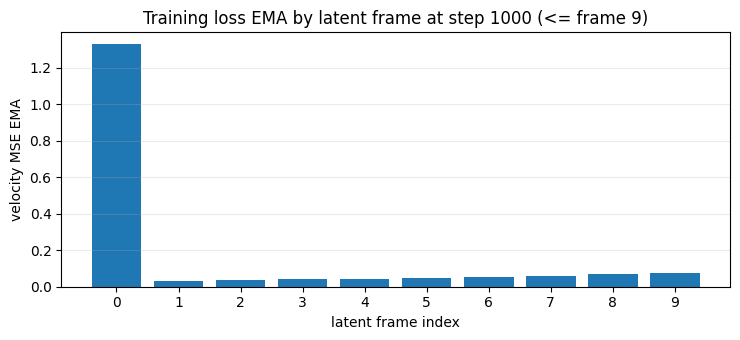

ssm-window:   3%|▎         | 1000/30000 [14:08<17:07:11,  2.13s/it, mse_ema=0.050040, seq=10, total_ema=0.050040]

[train init] active latent frame count at step 1001: 11


ssm-window:   4%|▍         | 1200/30000 [17:17<7:28:18,  1.07it/s, mse_ema=0.050066, seq=11, total_ema=0.050066] 

[train init] active latent frame count at step 1201: 12


ssm-window:   5%|▍         | 1400/30000 [20:34<7:49:01,  1.02it/s, mse_ema=0.049349, seq=12, total_ema=0.049349]

[train init] active latent frame count at step 1401: 13


ssm-window:   5%|▍         | 1499/30000 [22:18<8:11:15,  1.03s/it, mse_ema=0.056997, seq=13, total_ema=0.056997]

step 1500: 9e7adf609c925739 | nu=2.93e-03, rho=1.11 | left=ssm Wan flow 20 steps causal window L=1 | middle=ground truth | right=absolute error
pred_latents: min=-6.156, max=5.281, mean=-0.158, std=1.506 | gt_latents: min=-6.648, max=5.660, mean=-0.154, std=1.512 | pred_video: min=-1.000, max=1.000, mean=0.249, std=0.558 | gt_video: min=-1.000, max=1.000, mean=0.251, std=0.556


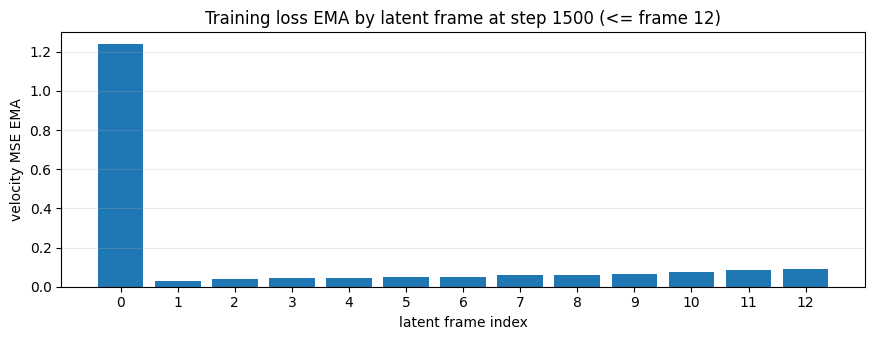

ssm-window:   5%|▌         | 1600/30000 [24:06<8:09:13,  1.03s/it, mse_ema=0.049426, seq=13, total_ema=0.049426] 

[train init] active latent frame count at step 1601: 14


ssm-window:   6%|▌         | 1800/30000 [27:40<8:21:44,  1.07s/it, mse_ema=0.053796, seq=14, total_ema=0.053796]

[train init] active latent frame count at step 1801: 15


ssm-window:   7%|▋         | 1999/30000 [31:23<8:39:18,  1.11s/it, mse_ema=0.058435, seq=15, total_ema=0.058435]

step 2000: 1db68f3cf097f3c2 | nu=2.90e-03, rho=1.19 | left=ssm Wan flow 20 steps causal window L=1 | middle=ground truth | right=absolute error
pred_latents: min=-5.250, max=6.219, mean=-0.156, std=1.534 | gt_latents: min=-5.191, max=6.059, mean=-0.157, std=1.521 | pred_video: min=-1.000, max=1.000, mean=0.259, std=0.545 | gt_video: min=-1.000, max=1.000, mean=0.262, std=0.544


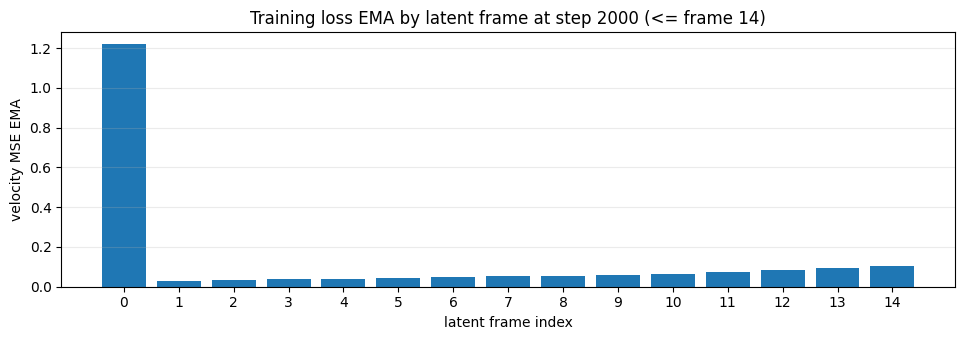

ssm-window:   7%|▋         | 2000/30000 [31:28<20:12:04,  2.60s/it, mse_ema=0.058435, seq=15, total_ema=0.058435]

[train init] active latent frame count at step 2001: 16


ssm-window:   7%|▋         | 2200/30000 [35:19<8:54:43,  1.15s/it, mse_ema=0.065566, seq=16, total_ema=0.065566] 

[train init] active latent frame count at step 2201: 17


ssm-window:   8%|▊         | 2400/30000 [39:19<9:10:41,  1.20s/it, mse_ema=0.057206, seq=17, total_ema=0.057206]

[train init] active latent frame count at step 2401: 18


ssm-window:   8%|▊         | 2499/30000 [41:25<9:30:31,  1.24s/it, mse_ema=0.055897, seq=18, total_ema=0.055897] 

step 2500: 3b3dcd685d40dd7a | nu=6.11e-04, rho=0.86 | left=ssm Wan flow 20 steps causal window L=1 | middle=ground truth | right=absolute error
pred_latents: min=-5.062, max=5.719, mean=-0.154, std=1.516 | gt_latents: min=-5.918, max=5.891, mean=-0.152, std=1.513 | pred_video: min=-1.000, max=1.000, mean=0.266, std=0.540 | gt_video: min=-1.000, max=1.000, mean=0.277, std=0.533


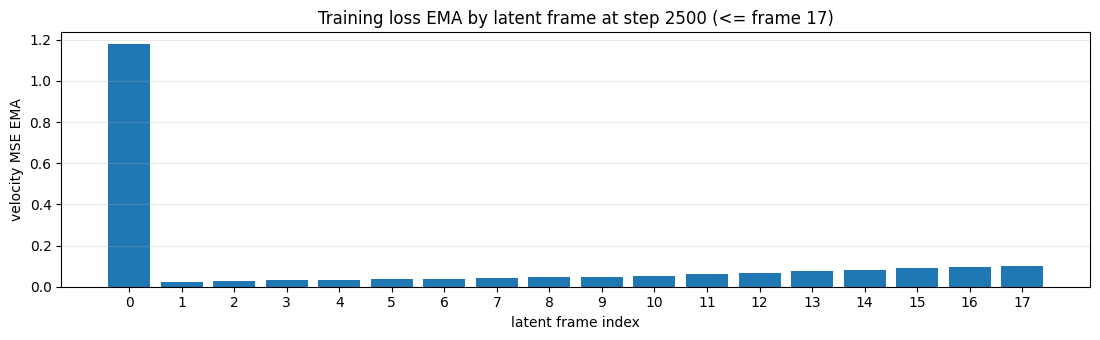

ssm-window:   9%|▊         | 2600/30000 [43:35<9:32:44,  1.25s/it, mse_ema=0.055086, seq=18, total_ema=0.055086] 

[train init] active latent frame count at step 2601: 19


ssm-window:   9%|▉         | 2800/30000 [47:53<9:37:42,  1.27s/it, mse_ema=0.062136, seq=19, total_ema=0.062136] 

[train init] active latent frame count at step 2801: 20


ssm-window:  10%|▉         | 2999/30000 [52:19<9:53:35,  1.32s/it, mse_ema=0.057778, seq=20, total_ema=0.057778] 

step 3000: d2985f13a7ff527c | nu=3.96e-04, rho=1.98 | left=ssm Wan flow 20 steps causal window L=1 | middle=ground truth | right=absolute error
pred_latents: min=-5.531, max=5.906, mean=-0.158, std=1.531 | gt_latents: min=-5.746, max=6.020, mean=-0.154, std=1.531 | pred_video: min=-1.000, max=1.000, mean=0.251, std=0.565 | gt_video: min=-1.000, max=1.000, mean=0.250, std=0.567


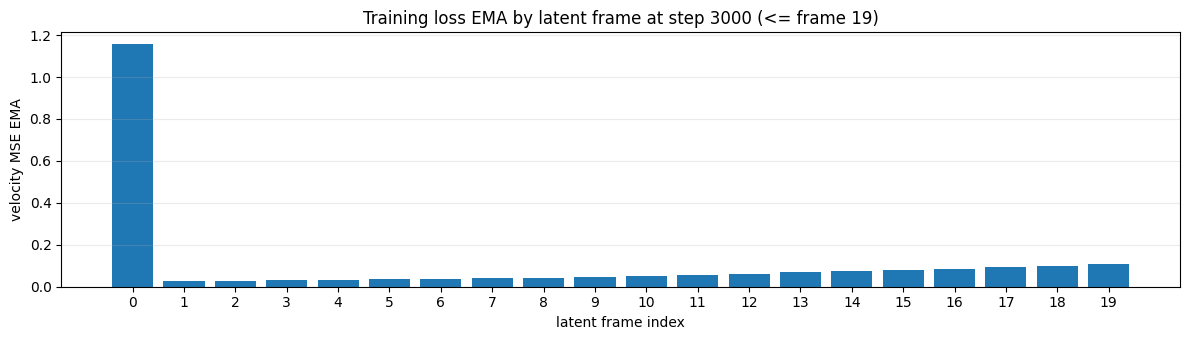

ssm-window:  10%|█         | 3000/30000 [52:25<23:19:48,  3.11s/it, mse_ema=0.057778, seq=20, total_ema=0.057778]

[train init] active latent frame count at step 3001: 21


ssm-window:  11%|█         | 3200/30000 [57:00<10:06:01,  1.36s/it, mse_ema=0.059035, seq=21, total_ema=0.059035]

[train init] active latent frame count at step 3201: 22


ssm-window:  11%|█▏        | 3400/30000 [1:01:42<10:24:59,  1.41s/it, mse_ema=0.060598, seq=22, total_ema=0.060598]

[train init] active latent frame count at step 3401: 23


ssm-window:  12%|█▏        | 3499/30000 [1:04:10<10:45:29,  1.46s/it, mse_ema=0.064348, seq=23, total_ema=0.064348]

step 3500: 2111e7aea8f6f921 | nu=2.17e-03, rho=0.519 | left=ssm Wan flow 20 steps causal window L=1 | middle=ground truth | right=absolute error
pred_latents: min=-5.500, max=6.062, mean=-0.151, std=1.530 | gt_latents: min=-5.688, max=5.859, mean=-0.153, std=1.536 | pred_video: min=-1.000, max=1.000, mean=0.248, std=0.571 | gt_video: min=-1.000, max=1.000, mean=0.251, std=0.574


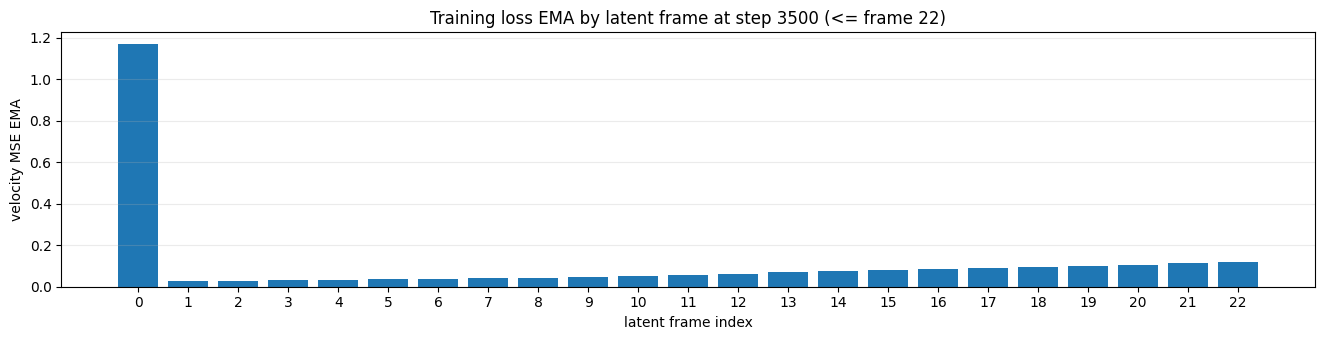

ssm-window:  12%|█▏        | 3600/30000 [1:06:44<10:42:07,  1.46s/it, mse_ema=0.064508, seq=23, total_ema=0.064508]

[train init] active latent frame count at step 3601: 24


ssm-window:  13%|█▎        | 3800/30000 [1:11:47<11:02:35,  1.52s/it, mse_ema=0.058194, seq=24, total_ema=0.058194]

[train init] active latent frame count at step 3801: 25


ssm-window:  13%|█▎        | 3999/30000 [1:16:59<11:49:33,  1.64s/it, mse_ema=0.065702, seq=25, total_ema=0.065702]

step 4000: 68d02290b4a3b4fc | nu=1.58e-03, rho=0.562 | left=ssm Wan flow 20 steps causal window L=1 | middle=ground truth | right=absolute error
pred_latents: min=-5.812, max=6.250, mean=-0.150, std=1.535 | gt_latents: min=-6.172, max=6.277, mean=-0.154, std=1.537 | pred_video: min=-1.000, max=1.000, mean=0.262, std=0.551 | gt_video: min=-1.000, max=1.000, mean=0.261, std=0.555


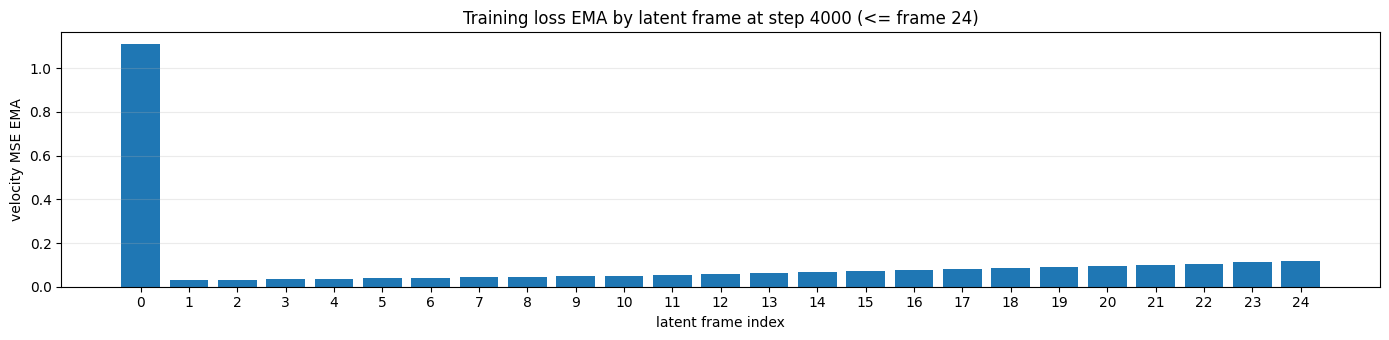

ssm-window:  13%|█▎        | 4000/30000 [1:17:06<26:50:47,  3.72s/it, mse_ema=0.065702, seq=25, total_ema=0.065702]

[train init] active latent frame count at step 4001: 26


ssm-window:  14%|█▍        | 4200/30000 [1:22:26<11:22:48,  1.59s/it, mse_ema=0.063983, seq=26, total_ema=0.063983]

[train init] active latent frame count at step 4201: 27


ssm-window:  15%|█▍        | 4400/30000 [1:27:54<11:37:52,  1.64s/it, mse_ema=0.062603, seq=27, total_ema=0.062603]

[train init] active latent frame count at step 4401: 28


ssm-window:  15%|█▍        | 4499/30000 [1:30:44<12:05:26,  1.71s/it, mse_ema=0.062541, seq=28, total_ema=0.062541]

step 4500: 99e7fbe7b6c30f8c | nu=8.01e-04, rho=1.02 | left=ssm Wan flow 20 steps causal window L=1 | middle=ground truth | right=absolute error
pred_latents: min=-5.188, max=6.250, mean=-0.164, std=1.538 | gt_latents: min=-5.359, max=6.078, mean=-0.166, std=1.543 | pred_video: min=-1.000, max=1.000, mean=0.253, std=0.562 | gt_video: min=-1.000, max=1.000, mean=0.243, std=0.573


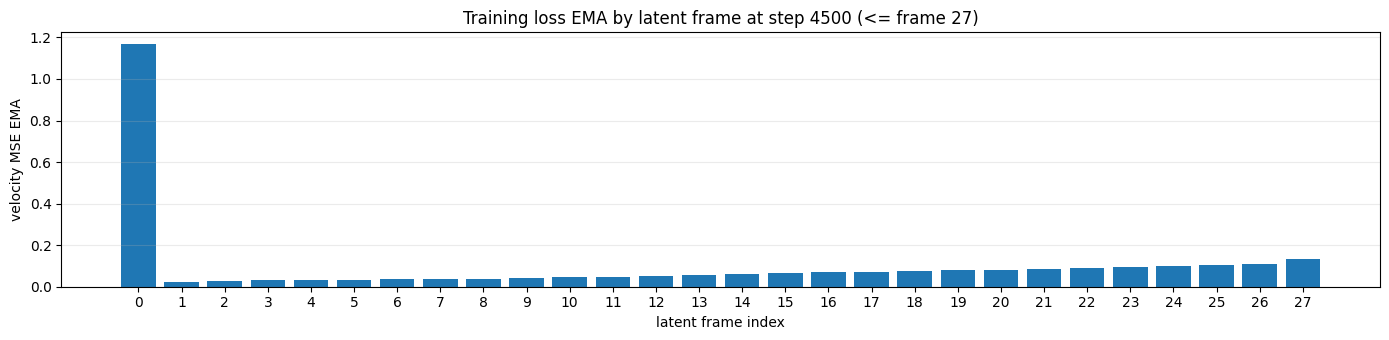

ssm-window:  15%|█▌        | 4600/30000 [1:33:40<11:52:02,  1.68s/it, mse_ema=0.064938, seq=28, total_ema=0.064938]

[train init] active latent frame count at step 4601: 29


ssm-window:  16%|█▌        | 4692/30000 [1:36:21<8:39:45,  1.23s/it, mse_ema=0.067147, seq=29, total_ema=0.067147] 
/home/azureuser/physics/navier/navier/model/build_checkpoint.py:328: UserWarning: W&B finish failed: Connection lost
  warnings.warn(f"W&B finish failed: {exc}")


KeyboardInterrupt: 

Error in callback <bound method _WandbInit._post_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x767a4984b0d0>> (for post_run_cell), with arguments args (<ExecutionResult object at 767b3f4d4650, execution_count=5 error_before_exec=None error_in_exec= info=<ExecutionInfo object at 767b3f5ee210, raw_cell="# Every EVAL_EVERY steps this samples one holdout .." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://ssh-remote%2Bazure/home/azureuser/physics/navier/autoreg.ipynb#X14sdnNjb2RlLXJlbW90ZQ%3D%3D> result=None>,),kwargs {}:


ConnectionResetError: Connection lost

In [5]:
# Every EVAL_EVERY steps this samples one holdout latent, conditions on
# its first latent frame, and displays prediction / ground truth / absolute error.
# Evaluation uses Wan flow sampling for EVAL_INFERENCE_STEPS scheduler steps.
# Configured transformer blocks are skipped deterministically during train/eval.
model, state = awl.train()
